## Cài đặt các thư viện cần thiết

In [1]:
!pip -q install -q kneed
!pip -q install tabulate

In [6]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from kneed import KneeLocator
from tabulate import tabulate

In [7]:
def display_table(df, max_rows=100):
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)   
    pd.set_option('display.max_rows', max_rows) 
    pd.set_option('display.colheader_justify', 'center') 
    display(df)

## **Phần 1: Phân tích dữ liệu**

### Phân tích tổng quan

In [8]:
df = pd.read_csv('Student_performance.csv')
df.head(5)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


**Sau khi quan sát dữ liệu nhóm rút ra như sau:**
- Bỏ trường dữ liệu không cần thiết: StudentID 
- GPA, GradeClass: có thể là nhãn và có mối quan hệ với nhau

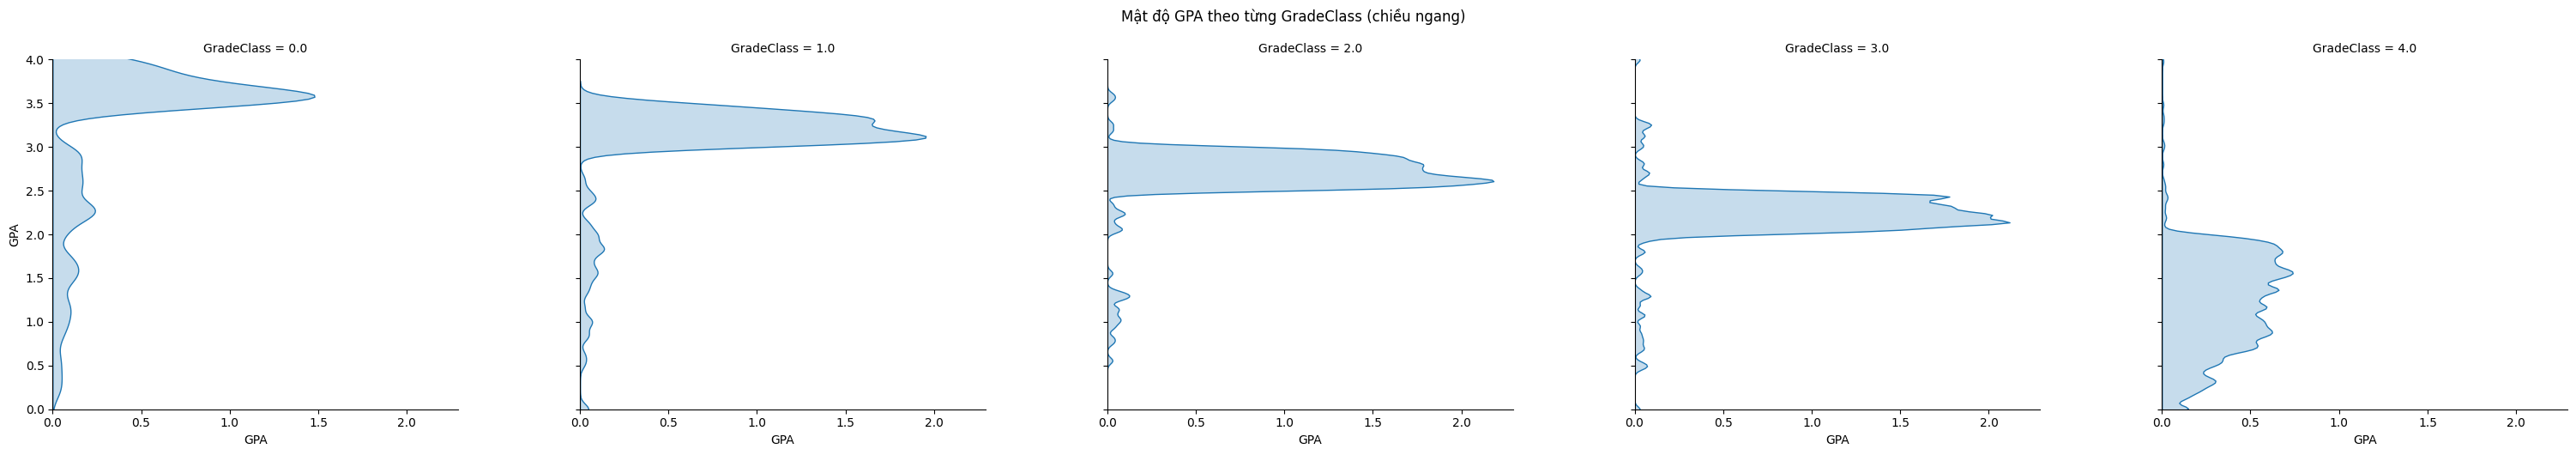

In [ ]:
df = df.drop(columns=['StudentID'])

## create a facetgrid with one subplot per each unique value in GradeClass, share y-axis (sharey=True)
g = sns.FacetGrid(df, col="GradeClass", height=5, aspect=1.2, sharey=True)

##plots KDE curve of the GPA column in each facet
g.map(sns.kdeplot, "GPA", fill=True, bw_adjust=0.3, vertical=True)

##ensure the y-axis consistent across all subplots
g.set(ylim=(df['GPA'].min(), df['GPA'].max()))

#adjust spacing between subplots and add a title
g.fig.subplots_adjust(wspace=0.3)
g.fig.suptitle("Mật độ GPA theo từng GradeClass (chiều ngang)", y=1.05)
plt.show()

 **GPA và GradeClass có mối liên hệ chặt chẽ, GPA càng cao thì GradeClass càng thấp (cho thấy học lực càng tốt).Cụ thể: ```GPA ≥ 3.5 tập trung ở GradeClass = 0, 3.0–3.5 ở GradeClass = 1, 2.5–3.0 ở GradeClass = 2, 2.0–2.5 ở GradeClass = 3, và < 2.0 ở GradeClass = 4```. Vì vậy nhóm em sẽ thử đi kiểm tra bằng các rule cơ bản**

In [ ]:
def rule_based_gradeclass(gpa):
    if gpa >= 3.5:
        return 0
    elif gpa >= 3.0:
        return 1
    elif gpa >= 2.5:
        return 2
    elif gpa >= 2.0:
        return 3
    else:
        return 4
df['Predicted_GradeClass'] = df['GPA'].apply(rule_based_gradeclass)

##find all rows where Predicted_GradeClass does not match GradeClass
mismatch = df[df['Predicted_GradeClass'] != df['GradeClass']]
mismatch_rate = len(mismatch) / len(df) * 100
print(f"Số dòng mismatch giữa GPA và GradeClass theo rule: {len(mismatch)} ({mismatch_rate:.2f}%)")
df.drop(columns=['Predicted_GradeClass'], inplace=True)

Số dòng mismatch giữa GPA và GradeClass theo rule: 168 (7.02%)



**Từ quan sát này cho thấy, GPA và GradeClass đều có thể xấp xỉ quy đổi sang lẫn nhau có 7.02% bản ghi là lệch theo rule-based nhưng vẫn có thể chấp nhận được, chính vì thế, các phân tích dữ liệu ở phía sau nhóm sẽ sử dụng 1 trong 2 để đại diện xét mối tương quan với các biến khác**


**Phân tích xem cột nào là numerical và cột nào là categorical**

In [11]:
columns = list(df.columns)
categoric_columns = []
numeric_columns = []
for i in columns:
    if len(df[i].unique()) > 5:
        numeric_columns.append(i)
    else:
        categoric_columns.append(i)     
print('Numerical features: ', numeric_columns)
print('Categorical features: ', categoric_columns)

Numerical features:  ['StudyTimeWeekly', 'Absences', 'GPA']
Categorical features:  ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']


**Phân tích thống kê chi tiết của các thuộc tính bao gồm phân phối, xu hướng trung tâm, độ phân tán và phát hiện các điểm ngoại lai theo phương pháp IQR và các điểm dữ liệu bị thiếu để đánh giá chất lượng dữ liệu**

In [12]:
desc = df.describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc['lower-thres outlier'] = desc['25%'] - 1.5 * desc['IQR']
desc['upper-thres outlier'] = desc['75%'] + 1.5 * desc['IQR']
desc['missing data'] = df.isna().sum().reindex(desc.index).fillna(0).astype(int)
desc['outlier detected'] = '-'
for col in numeric_columns:
    Q1, Q3, IQR = desc.loc[col, '25%'], desc.loc[col, '75%'], desc.loc[col, 'IQR']
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    if df[col].min() < lower or df[col].max() > upper:
        desc.loc[col, 'outlier detected'] = 'Yes'
    else:
        desc.loc[col, 'outlier detected'] = 'No'
stats = desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'lower-thres outlier', 'upper-thres outlier', 'outlier detected', 'missing data']].round(4)
display_table(stats)

,count,mean,std,min,25%,50%,75%,max,IQR,lower-thres outlier,upper-thres outlier,outlier detected,missing data
Age,2392.0,16.4686,1.1238,15.0000,15.0000,16.0000,17.0000,18.0000,2.0000,12.0000,20.0000,-,0
Gender,2392.0,0.5109,0.5000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,-1.5000,2.5000,-,0
Ethnicity,2392.0,0.8775,1.0285,0.0000,0.0000,0.0000,2.0000,3.0000,2.0000,-3.0000,5.0000,-,0
ParentalEducation,2392.0,1.7462,1.0004,0.0000,1.0000,2.0000,2.0000,4.0000,1.0000,-0.5000,3.5000,-,0
StudyTimeWeekly,2392.0,9.7720,5.6528,0.0011,5.0431,9.7054,14.4084,19.9781,9.3653,-9.0049,28.4564,No,0
Absences,2392.0,14.5414,8.4674,0.0000,7.0000,15.0000,22.0000,29.0000,15.0000,-15.5000,44.5000,No,0
Tutoring,2392.0,0.3014,0.4590,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,-1.5000,2.5000,-,0
ParentalSupport,2392.0,2.1221,1.1228,0.0000,1.0000,2.0000,3.0000,4.0000,2.0000,-2.0000,6.0000,-,0
Extracurricular,2392.0,0.3834,0.4863,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,-1.5000,2.5000,-,0
Sports,2392.0,0.3035,0.4599,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,-1.5000,2.5000,-,0


**--> Kết quả phân tích thống kê cho thấy tập dữ liệu có chất lượng tốt mà không có giá trị thiếu và không có điểm ngoại lai trong các biến numerical, với tất cả các giá trị nằm trong ngưỡng hợp lý được xác định bởi phương pháp IQR**

**Xét phân bố của từng loại numerical và categorical**

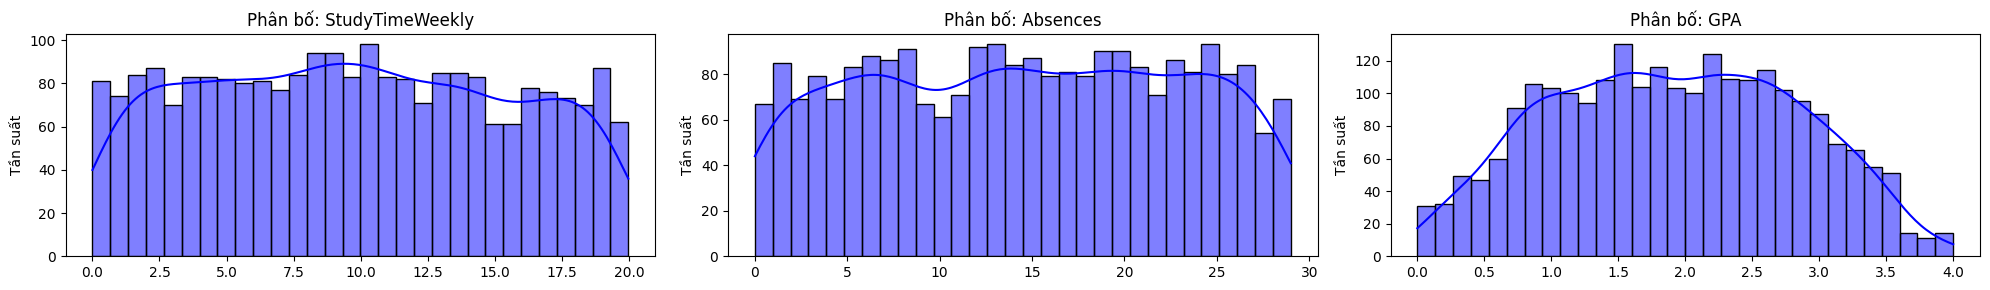

In [13]:
plt.figure(figsize=(20, 2 * len(numeric_columns)//3 + 1))
for i, feature in enumerate(numeric_columns):
    plt.subplot((len(numeric_columns)-1)//3 + 1, 3, i+1)
    sns.histplot(data=df, x=feature, bins=30, kde=True, color='blue')
    plt.title(f'Phân bố: {feature}')
    plt.xlabel('')
    plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

**Phân bố StudyTimeWeekly và Absences khá đồng đều, cho thấy thời gian học tập và số buổi vắng mặt của học sinh trải rộng trên toàn bộ khoảng giá trị, không tập trung quá nhiều ở một mức cụ thể nào. Trong khi đó, GPA có dạng phân bố gần giống hình chuông, hơi lệch nhẹ, với phần lớn học sinh đạt GPA từ 1.5 đến 2.5.**

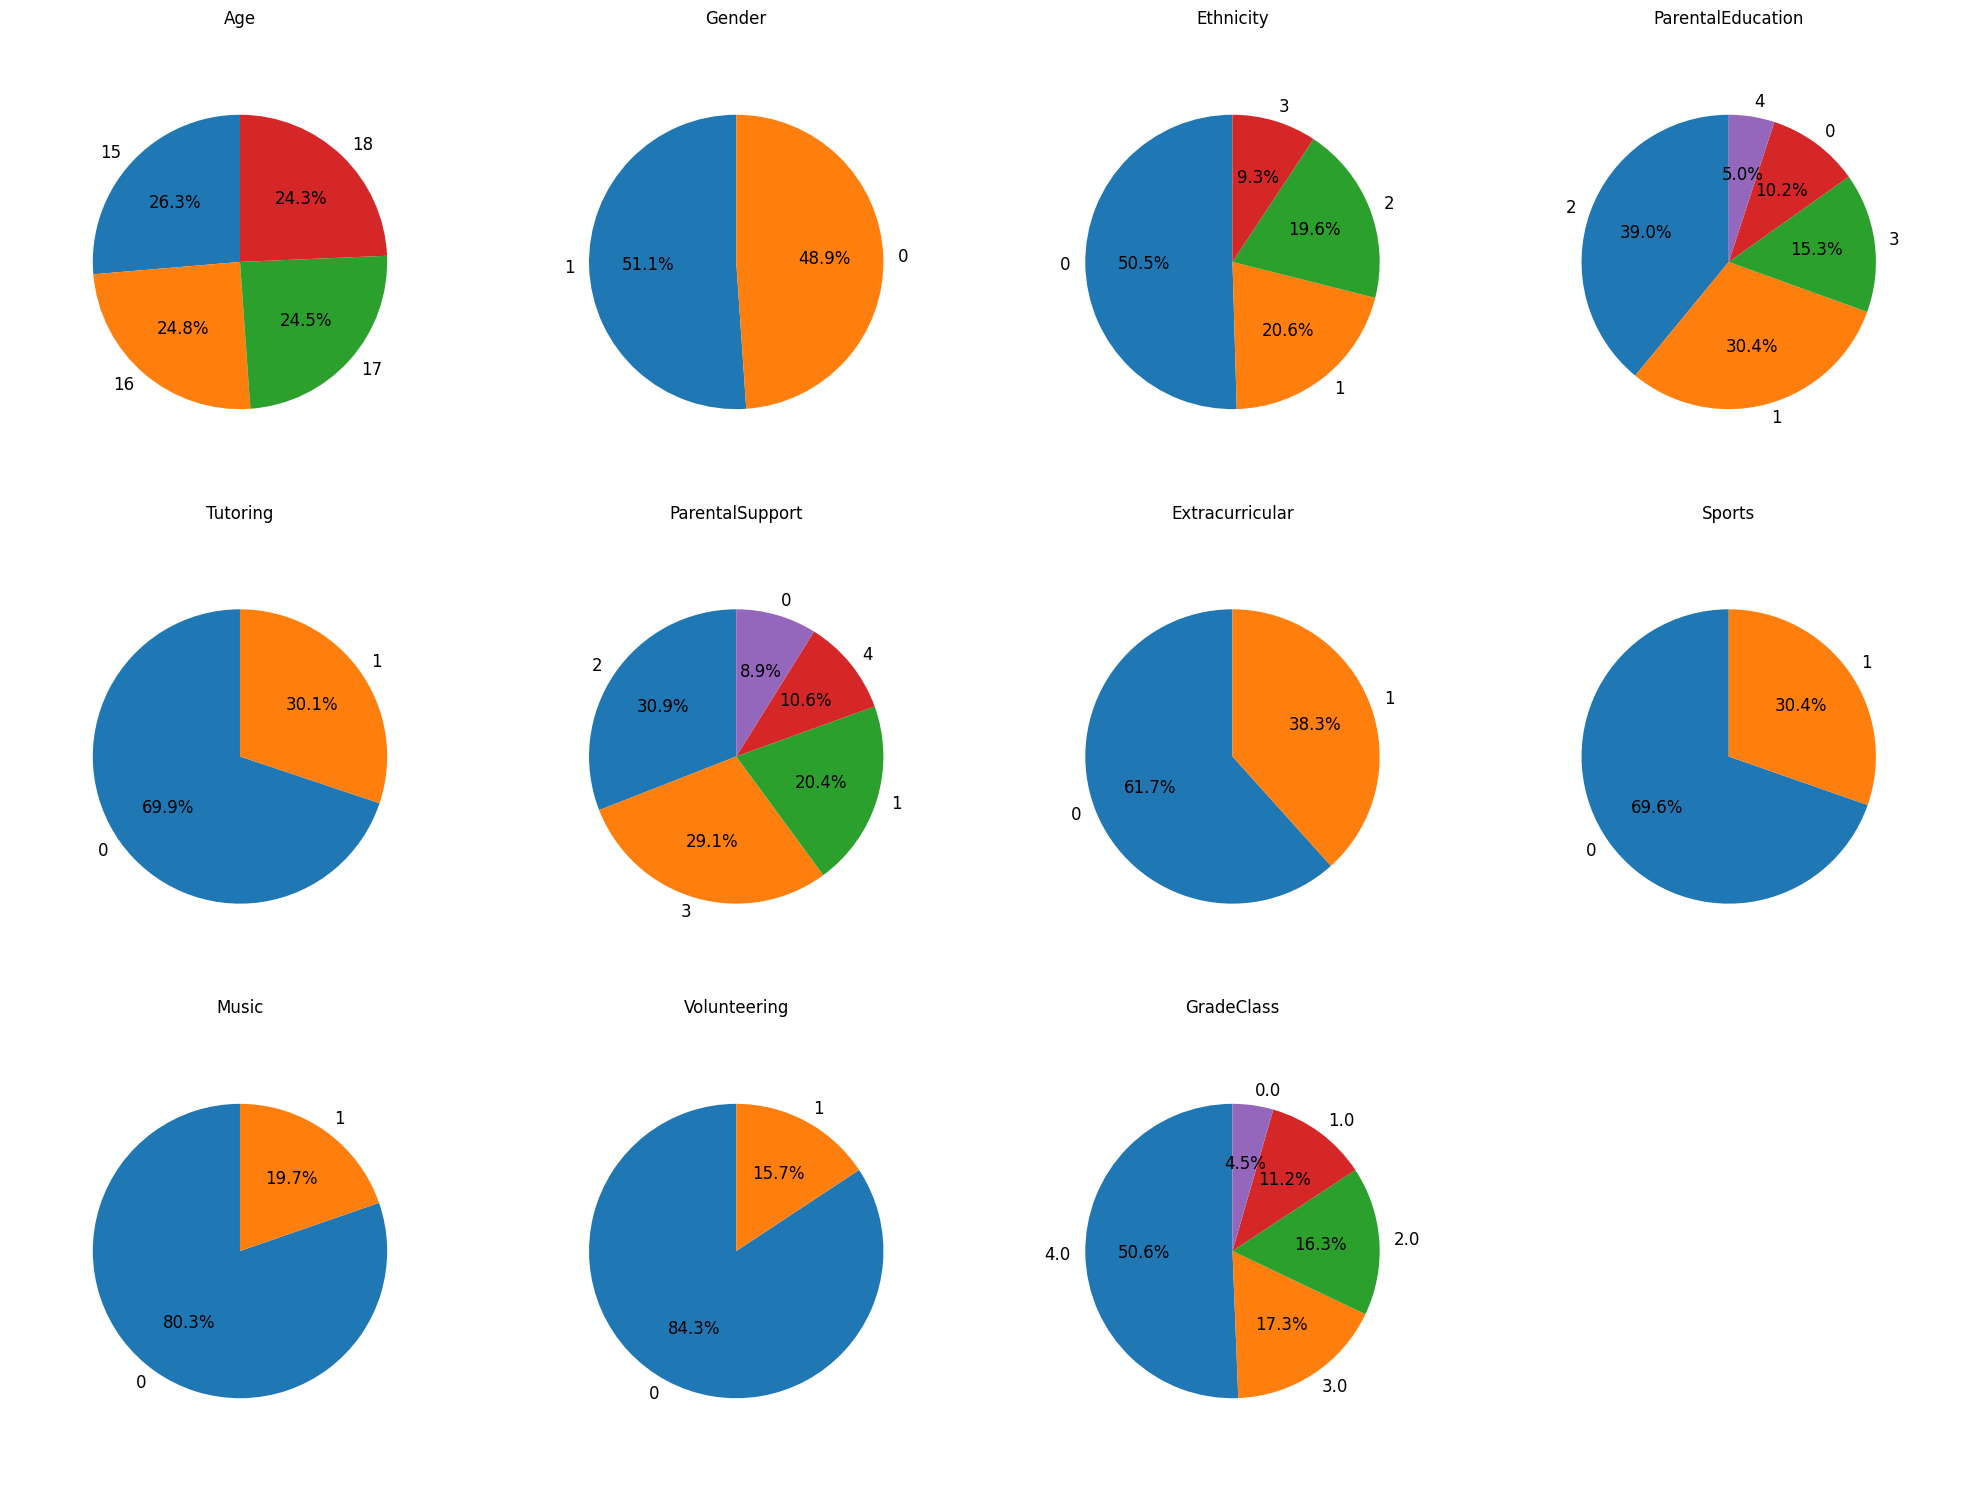

In [14]:
n = len(categoric_columns)
cols = 4
rows = (n - 1) // cols + 1
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
axes = axes.flatten()
for i, feature in enumerate(categoric_columns):
    ax = axes[i]
    data = df[feature].value_counts()
    ax.pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 12},
        radius=0.8
    )
    ax.set_title(f'{feature}', fontsize=12)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()

**Phân tích các phân bố của biến categorical**
- Dữ liệu cho thấy phân bố độ tuổi khá đồng đều giữa các nhóm từ 15-18 tuổi, với mỗi nhóm chiếm khoảng 24-26% tổng số.
- Tỉ lệ nam và nữ khá cân bằng, với nam chiếm 51.09% và nữ chiếm 48.91%.
- Về dân tộc, nhóm "0" chiếm đa số với 50.46%, tiếp theo là nhóm "1" và "2" chiếm lần lượt 20.61% và 19.65%, trong khi nhóm "3" chỉ chiếm 9.28%.
- Trình độ học vấn của phụ huynh chủ yếu tập trung ở mức "2" (39.05%) và mức "1" (30.43%), trong khi mức cao nhất "4" chỉ chiếm 5.02%.
- Đa số học sinh không tham gia học thêm, chiếm 69.86%, trong khi chỉ có 30.14% tham gia.
- Sự hỗ trợ từ phụ huynh phân bố đa dạng nhưng chủ yếu ở mức "2" (30.94%) và mức "3" (29.14%), trong khi mức thấp nhất "0" chỉ chiếm 8.86%.
- Đa số học sinh không tham gia hoạt động ngoại khóa (61.66%), thể thao (69.65%), âm nhạc (80.31%), và tình nguyện viên (84.28%).
- Về điểm số, nửa số học sinh đạt được mức "4" cao nhất (50.63%), trong khi mức thấp nhất "0" chỉ chiếm 4.47%, cho thấy phần lớn học sinh có thành tích học tập không tốt.

### Phân tích mối liên kết giữa các đặc trưng

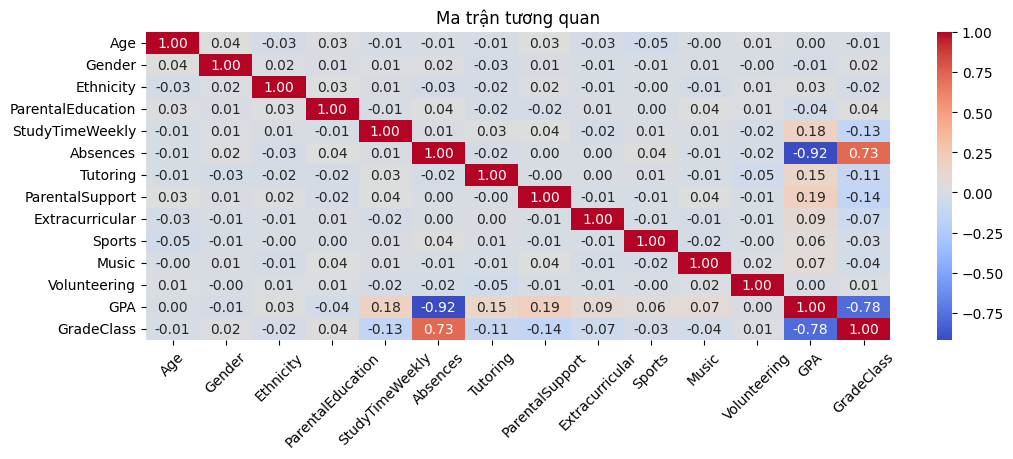

In [15]:
plt.figure(figsize=(12,4))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.xticks(rotation=45)
plt.show()

**Quan sát ma trận tương quan ta thấy chỉ có một vài đặc trưng là tương quan mạnh với nhau, còn lại là tương quan khá yếu, ta cần xử lý kĩ vẫn đề này để không gây nhiễu cho mô hình**

#### 12 đặc trưng này sẽ được phân thành 3 nhóm để giải thích dữ liệu tốt hơn: 
- **Đặc điểm nhân khẩu học**
- **Yếu tố hỗ trợ học tập**
- **Hoạt động ngoại khóa**

**Question:**
- Các nhóm dữ liệu này ảnh hưởng như thế nào đến kết quả học tập?
- Các yếu tố nào quan trọng nhất để phân biệt các cụm học sinh?
- Các cụm học sinh có đặc điểm gì nổi bật?

### Phân tích đặc điểm nhân khẩu học

In [ ]:
def plot_percentage_stacked_bars(df, features, target_col, group_name="", figsize=(16,4), colors=None):
    fig, axes = plt.subplots(1,len(features),figsize=figsize)
    fig.suptitle(f"Phân bố {target_col} theo nhóm {group_name}" if group_name else f"Phân bố {target_col} theo các biến",fontsize=14,y=1.05)
    colors = colors or sns.color_palette("Accent",len(df[target_col].unique()))
    axes = [axes] if len(features)==1 else axes
    for i,f in enumerate(features):
        ax = axes[i]
        counts = pd.crosstab(pd.cut(df[f],bins=4,labels=["Thấp","Trung bình","Cao","Rất cao"]) if f in numeric_columns else df[f],df[target_col])
        pcts = counts.div(counts.sum(axis=1),axis=0)*100
        pcts.plot(kind='bar',stacked=True,ax=ax,color=colors)
        for r in range(pcts.shape[0]): 
            y=0
            for c in range(pcts.shape[1]):
                v=pcts.iloc[r,c]
                if v>=2: ax.text(r,y+v/2,f'{v:.1f}%',ha='center',va='center',color='black',fontweight='bold',fontsize=7)
                y+=v
        ax.set_title(f'{f}',fontsize=12)
        ax.set_ylabel('Phần trăm (%)')
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        (ax.legend(title=target_col,bbox_to_anchor=(1.05,1),loc='upper left') if i==len(features)-1 else ax.get_legend().remove())
    plt.tight_layout()
    return fig,axes

In [17]:
def plot_pca_correlation_biplot(df, features, target_col=None, figsize=(8, 6), random_state=42):
    X = StandardScaler().fit_transform(df[features].values)
    pca = PCA(n_components=2, random_state=random_state)
    comps = pca.fit_transform(X)
    result_df = pd.DataFrame(comps, columns=['Dim1', 'Dim2'])
    if target_col is not None:
        result_df[target_col] = df[target_col].reset_index(drop=True)
    plt.figure(figsize=figsize)
    if target_col is None:
        plt.scatter(result_df['Dim1'], result_df['Dim2'], s=50, alpha=0.8)
    elif np.issubdtype(df[target_col].dtype, np.number):
        sc = plt.scatter(result_df['Dim1'], result_df['Dim2'], c=result_df[target_col], cmap='rainbow', s=50, alpha=0.8)
        plt.colorbar(sc, label=target_col)
    else:
        print("Chỉ áp dụng numeric target")
        plt.scatter(result_df['Dim1'], result_df['Dim2'], s=50, alpha=0.8)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    for i, feat in enumerate(features):
        plt.arrow(0, 0, loadings[i,0], loadings[i,1], color='black', alpha=0.8, head_width=0.05)
        plt.text(loadings[i,0]*1.15, loadings[i,1]*1.15, feat, color='black', fontweight='bold', ha='center', va='center')
    plt.title(f"PCA Biplot" + (f" (hue={target_col})" if target_col else ""))
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

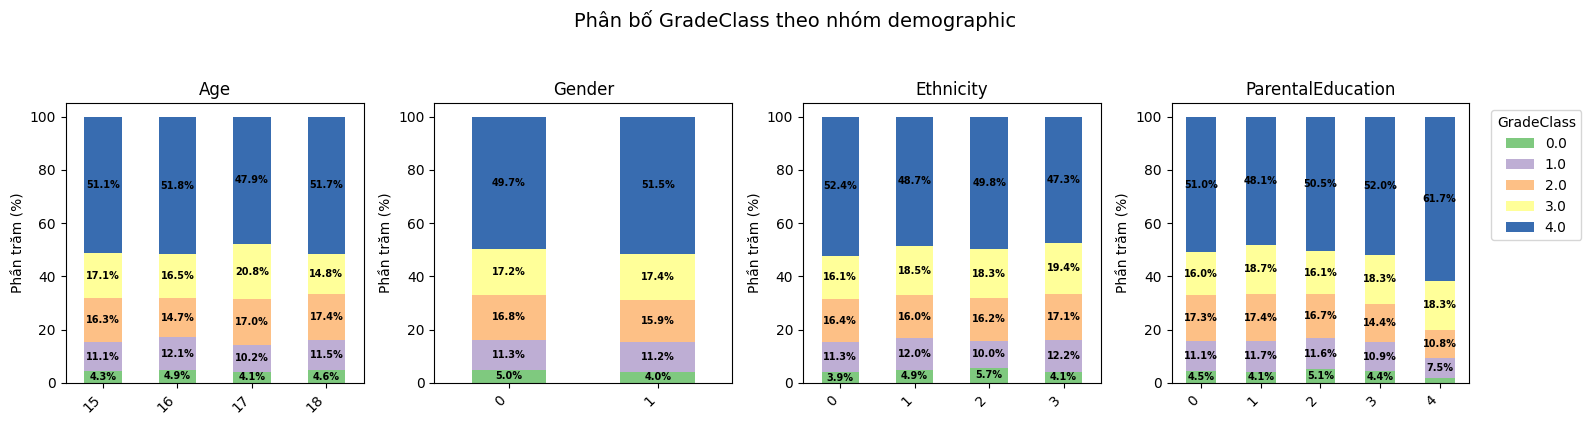

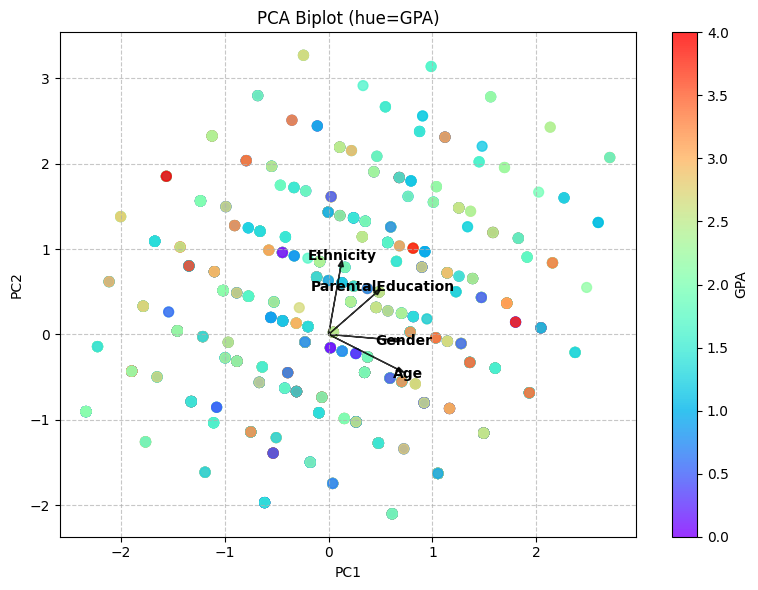

In [18]:
demographic_features = ['Age', 'Gender', 'Ethnicity', 'ParentalEducation']
fig, axes = plot_percentage_stacked_bars(df=df, features=demographic_features, group_name='demographic', target_col='GradeClass', figsize=(16, 4))
plot_pca_correlation_biplot(df=df, target_col='GPA', features=demographic_features)
plt.show()

**Nhận xét về các đặc điểm nhân khẩu học**:
  - **Age**: GradeClass 4 chiếm tỷ lệ cao nhất ở mọi nhóm tuổi (47-52%), cho thấy nhiều học sinh có điểm số thấp. Học sinh 17 tuổi có tỷ lệ GradeClass 4 thấp nhất (47.9%) nên có kết quả học tập tốt hơn các nhóm tuổi khác.
  - **Gender**: Phân phối GradeClass giữa hai giới tính gần như giống hệt nhau, với khoảng 50% ở GradeClass 4, cho thấy không có sự khác biệt về thành tích học tập giữa các giới.
  - **Ethnicity**: Nhóm 0 có tỷ lệ GradeClass 4 cao nhất (52.4%) nên có thành tích học tập kém hơn, trong khi nhóm 3 có tỷ lệ GradeClass 4 thấp nhất (47.3%) nên có kết quả học tập tốt hơn.
  - **ParentalEducation**: Có mối tương quan nghịch - khi trình độ học vấn của phụ huynh tăng, tỷ lệ học sinh có điểm kém (GradeClass 4) cũng tăng theo. Phụ huynh có học vấn cao nhất (mã 4) có con với tỷ lệ GradeClass 4 lên tới 61.7%. Ở đây **ParentalEducation** là có mối tương quan rõ nhất.

**Phân tích PCA Biplot của các biến nhân khẩu học và mối quan hệ với GPA**:
  - **Các trục chính**: PC1 và PC2 tạo không gian hai chiều biểu diễn dữ liệu, giữ lại nhiều phương sai nhất từ dữ liệu gốc.
  - **Mũi tên loading**:
     - **ParentalEducation**: Có loading mạnh theo hướng tích cực của PC1, thể hiện ảnh hưởng lớn đến thành phần chính thứ nhất.
     - **Ethnicity**: Có loading tương đối mạnh theo chiều dương của PC2.
     - **Gender**: Có loading theo hướng âm của PC2 và nhẹ về phía PC1.
     - **Age**: Có loading chủ yếu theo hướng âm của PC2.
  - **Phân bố GPA**:
     - Thang màu biểu thị GPA từ 0.0 (tím) đến 4.0 (đỏ).
     - Xu hướng rõ ràng: điểm GPA cao (màu vàng, cam, đỏ) thường phân bố nhiều hơn về phía dương của PC1.
     - Điểm GPA thấp (màu xanh dương, tím) thường nằm về phía âm của PC1.
  - **Mối quan hệ giữa các biến và GPA**:
     - **ParentalEducation** có mối tương quan dương với GPA: Sinh viên có cha mẹ học vấn cao thường có GPA cao hơn.
     - **Age** và **Gender** có ảnh hưởng phức tạp, không thể thấy xu hướng rõ ràng.
     - **Ethnicity** có một số ảnh hưởng, nhưng không mạnh như ParentalEducation.
  - **Mối tương quan giữa các biến**:
     - **ParentalEducation** và **Ethnicity** tạo góc nhỏ hơn 90 độ, cho thấy có tương quan dương.
     - **Age** và **Gender** cũng có mối tương quan với nhau (góc giữa chúng nhỏ hơn 90 độ).
     - **ParentalEducation** và **Age** gần như vuông góc, thể hiện ít tương quan.

**Kết luận**: Trong các yếu tố nhân khẩu học, học vấn của cha mẹ (ParentalEducation) có ảnh hưởng rõ ràng nhất đến GPA của sinh viên. Các yếu tố khác như dân tộc, giới tính và tuổi cũng có ảnh hưởng nhưng không mạnh bằng.


### Các yếu tố khác giúp hỗ trợ học tập

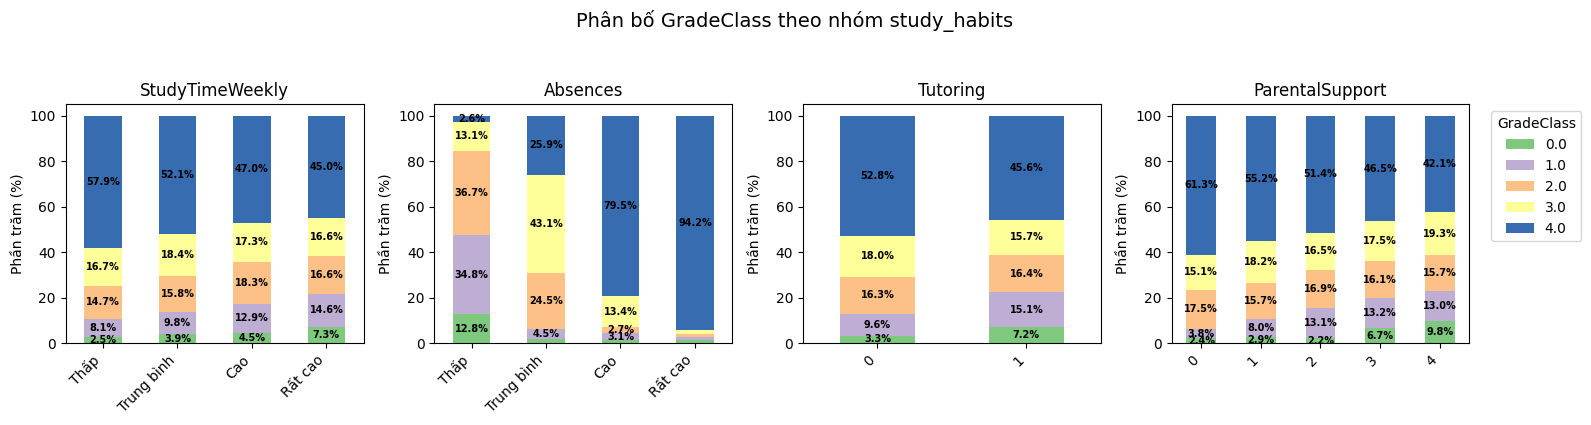

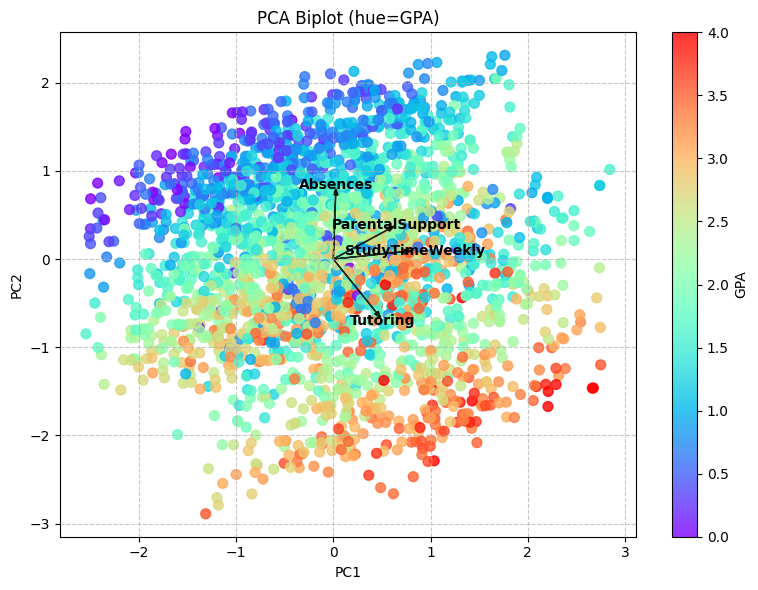

In [19]:
study_habits_features = ['StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport']
fig, axes = plot_percentage_stacked_bars(df=df, features=study_habits_features, group_name='study_habits', target_col='GradeClass', figsize=(16, 4))
plot_pca_correlation_biplot(df=df, target_col='GPA', features=study_habits_features)
plt.show()

**Nhận xét về các yếu tố hỗ trợ học tập**:
  - **StudyTimeWeekly**: Thời gian học càng cao thì tỷ lệ GradeClass 4 càng thấp (giảm từ 57.9% xuống 45%), cho thấy học sinh dành nhiều thời gian học tập có kết quả học tập tốt hơn.
  - **Absences**: Có mối tương quan mạnh mẽ - tỷ lệ vắng mặt càng cao thì tỷ lệ GradeClass 4 càng cao. Nhóm vắng mặt "Rất cao" có tới 94.2% học sinh thuộc GradeClass 4 (điểm thấp), trong khi nhóm vắng mặt "Thấp" chỉ có 2.6%.
  - **Tutoring**: Học sinh có gia sư (mã 1) có tỷ lệ GradeClass 4 thấp hơn (45.6%) so với học sinh không có gia sư (52.8%), cho thấy việc có gia sư giúp cải thiện kết quả học tập.
  - **ParentalSupport**: Có mối tương quan rõ rệt - khi mức độ hỗ trợ từ phụ huynh tăng (từ 0 đến 4), tỷ lệ học sinh có điểm kém (GradeClass 4) giảm đáng kể từ 61.3% xuống 42.1%.
  - Học sinh nhận được sự hỗ trợ cao nhất từ phụ huynh (mã 4) có tỷ lệ GradeClass 0 (điểm cao nhất) cao nhất (9.8%), gấp hơn 4 lần so với học sinh không được hỗ trợ (2.4%).
  - Sự hỗ trợ của phụ huynh dường như là yếu tố có ảnh hưởng mạnh mẽ đến thành tích học tập, với mỗi mức tăng của sự hỗ trợ đều dẫn đến cải thiện rõ rệt trong phân bố điểm số.

**Phân tích PCA Biplot của các biến thói quen học tập và mối quan hệ với GPA**:
  - **Các trục chính**: PC1 và PC2 biểu diễn hai thành phần chính giữ lại nhiều thông tin nhất từ dữ liệu gốc, tạo không gian hai chiều để phân tích.
  - **Mũi tên loading**:
     - **StudyTimeWeekly**: Có loading mạnh theo hướng dương của PC1, chỉ ra thời gian học hàng tuần là yếu tố quan trọng quyết định PC1.
     - **ParentalSupport**: Có loading theo hướng dương của PC1 và nhẹ về phía âm của PC2.
     - **Tutoring**: Có loading mạnh theo hướng dương của PC2, là yếu tố chính tác động đến PC2.
     - **Absences**: Có loading theo hướng âm của PC2, ngược chiều với Tutoring.
  - **Phân bố GPA**:
     - Thang màu từ tím (0.0) đến đỏ (4.0) thể hiện GPA.
     - Xu hướng rõ ràng: Sinh viên có GPA cao (màu đỏ, cam) tập trung chủ yếu ở phía trên bên phải của biểu đồ (PC1 dương, PC2 dương).
     - Sinh viên có GPA thấp (màu tím, xanh dương) tập trung ở phía dưới bên trái của biểu đồ (PC1 âm, PC2 âm).
  - **Mối quan hệ giữa các biến và GPA**:
     - **StudyTimeWeekly** có tương quan dương mạnh với GPA: Sinh viên dành nhiều thời gian học tập hàng tuần thường có GPA cao hơn.
     - **ParentalSupport** cũng có tương quan dương với GPA: Sự hỗ trợ từ phụ huynh góp phần vào thành tích học tập tốt.
     - **Tutoring** có tác động tích cực đến GPA: Sinh viên tham gia gia sư thường có GPA cao hơn.
     - **Absences** có tương quan âm với GPA: Sinh viên vắng mặt nhiều thường có GPA thấp hơn.
  - **Mối tương quan giữa các biến**:
     - **StudyTimeWeekly** và **ParentalSupport** tạo góc nhỏ, cho thấy tương quan dương mạnh: Sinh viên có sự hỗ trợ từ phụ huynh thường dành nhiều thời gian học tập hơn.
     - **Tutoring** và **Absences** tạo góc gần 180 độ, thể hiện tương quan âm: Sinh viên tham gia gia sư thường có ít vắng mặt hơn.
     - **StudyTimeWeekly** và **Tutoring** tạo góc khoảng 90 độ, cho thấy ít tương quan giữa thời gian học và việc tham gia gia sư.

**Kết luận**: Trong các yếu tố thói quen học tập, thời gian học hàng tuần (StudyTimeWeekly) và sự hỗ trợ từ phụ huynh (ParentalSupport) có ảnh hưởng tích cực nhất đến GPA. Việc tham gia gia sư (Tutoring) cũng có tác động tích cực, trong khi số lần vắng mặt (Absences) có ảnh hưởng tiêu cực đến thành tích học tập.


### Hoạt động ngoại khóa

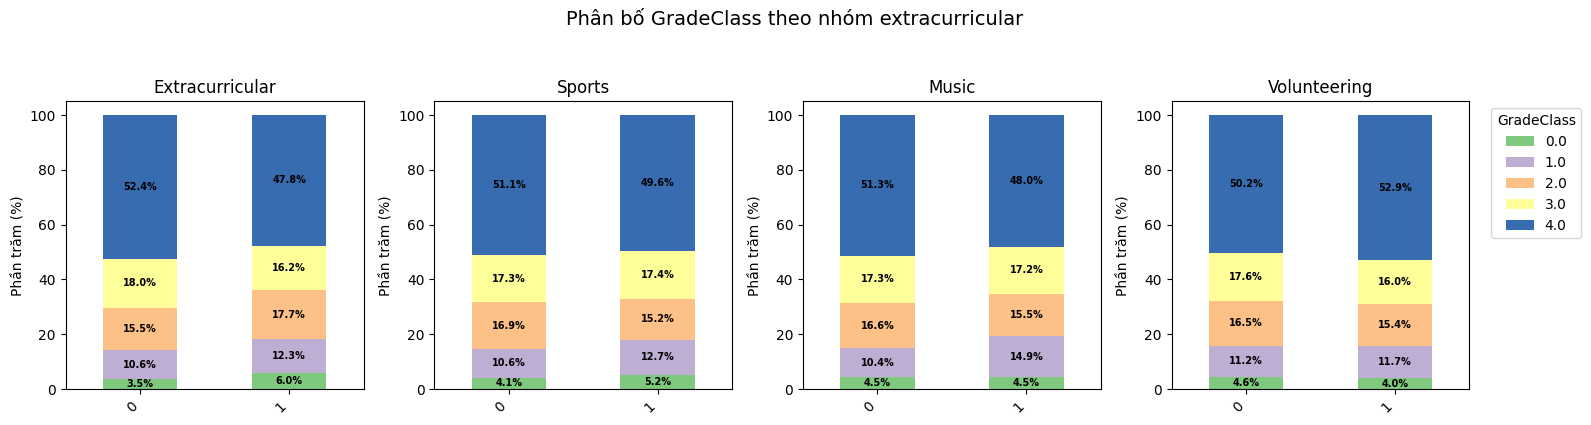

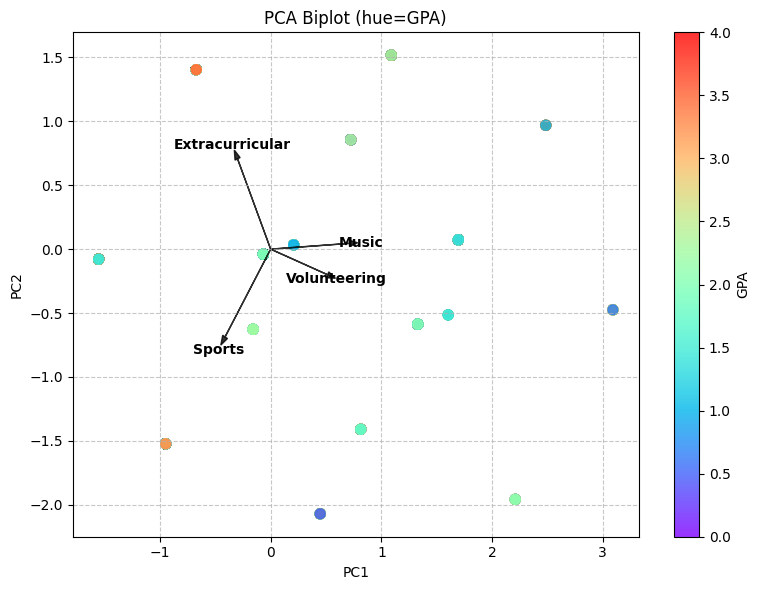

In [20]:
extracurricular_features = ['Extracurricular', 'Sports', 'Music', 'Volunteering']
fig, axes = plot_percentage_stacked_bars(df=df, features=extracurricular_features, group_name='extracurricular', target_col='GradeClass', figsize=(16, 4))
plot_pca_correlation_biplot(df=df, target_col='GPA', features=extracurricular_features)
plt.show()

**Nhận xét về các hoạt động ngoại khóa**:
   - **Extracurricular, Sports, Music và Volunteering**: Các hoạt động ngoại khóa này đều có tác động rất yếu đến phân bố GradeClass khi tỷ lệ giữa nhóm tham gia và không tham gia chênh lệch rất nhỏ, cho thấy không có hoạt động ngoại khóa cụ thể nào ảnh hưởng đáng kể đến thành tích học tập.
   - Do đó cần tạo biến kết hợp để tăng tính tương quan.

**Phân tích PCA Biplot của các biến hoạt động ngoại khóa và mối quan hệ với GPA**:
  - **Các trục chính**: PC1 và PC2 biểu diễn hai thành phần chính từ dữ liệu các hoạt động ngoại khóa, tạo không gian phân tích hai chiều.
  - **Mũi tên loading**:
     - **Extracurricular**: Có loading mạnh theo hướng âm của PC2, cho thấy tầm quan trọng trong việc phân biệt theo trục dọc.
     - **Sports**: Có loading mạnh theo hướng dương của PC2 và hơi âm của PC1, nằm gần như đối diện với Extracurricular.
     - **Music**: Có loading nhẹ theo hướng âm của PC2 và dương của PC1.
     - **Volunteering**: Có loading nhẹ theo hướng dương của PC2 và PC1.
  - **Phân bố GPA**:
     - Thang màu từ tím (0.0) đến đỏ (4.0) biểu thị GPA.
     - Không có mẫu phân bố rõ ràng theo GPA trong không gian PC1-PC2, điểm dữ liệu có GPA cao và thấp phân tán khá đồng đều.
     - Có một số điểm GPA cao (màu xanh lá, cam) ở các vị trí khác nhau trên biểu đồ.
  - **Mối quan hệ giữa các biến và GPA**:
     - Không thể nhận thấy mối tương quan mạnh giữa bất kỳ hoạt động ngoại khóa cụ thể nào với GPA.
     - Các biến hoạt động ngoại khóa đều có mũi tên loading khá ngắn, cho thấy ảnh hưởng tương đối yếu đến sự biến đổi của dữ liệu.
     - Không có hoạt động ngoại khóa nào rõ ràng hướng về khu vực tập trung GPA cao hoặc thấp.
  - **Mối tương quan giữa các biến**:
     - **Sports** và **Extracurricular** tạo góc gần 180 độ, cho thấy mối tương quan âm mạnh: Sinh viên tham gia nhiều hoạt động thể thao thường có ít thời gian cho các hoạt động ngoại khóa khác.
     - **Volunteering** và **Music** tạo góc khoảng 90 độ, cho thấy ít tương quan giữa hai hoạt động này.
     - **Sports** và **Volunteering** tạo góc nhỏ, thể hiện tương quan dương: Sinh viên tham gia thể thao cũng thường tham gia hoạt động tình nguyện.

**Kết luận**: Không thể xác định rõ mối quan hệ giữa các hoạt động ngoại khóa và GPA từ biểu đồ này. Các hoạt động ngoại khóa có vẻ không có ảnh hưởng đáng kể đến GPA của sinh viên. Tuy nhiên, có mối tương quan âm giữa tham gia thể thao và các hoạt động ngoại khóa khác, cho thấy sinh viên thường tập trung vào một loại hoạt động ngoại khóa cụ thể thay vì tham gia nhiều loại.


## **Phần 2: PreProcessing**

**Question: Feature engineering có cải thiện chất lượng phân cụm không?**

**Dùng PCA để đánh giá mức độ đóng góp của các biến vào phương sai tổng thể của dữ liệu, từ đó chọn ra những đặc trưng quan trọng nhất. PCA giúp giảm chiều dữ liệu, giữ lại các thông tin quan trọng, loại bỏ các biến ít đóng góp, giảm nhiễu, tăng hiệu quả phân tích**

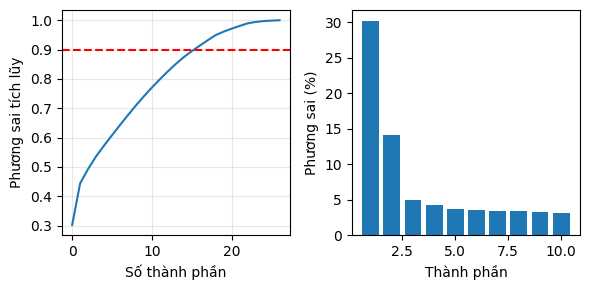

Cần 17 thành phần để đạt 90% phương sai
PC1 (30.20%): GPA, Absences, GradeClass_4.0
PC2 (14.18%): StudyTimeWeekly, Absences, ParentalSupport_1
PC3 (4.92%): ParentalEducation_2, ParentalEducation_1, ParentalSupport_2
PC4 (4.29%): ParentalSupport_2, ParentalSupport_3, Age_17
PC5 (3.67%): Age_16, Gender_1, Extracurricular_1
PC6 (3.54%): Gender_1, Age_18, Age_17
PC7 (3.47%): Age_17, Age_18, Gender_1
PC8 (3.39%): Extracurricular_1, ParentalSupport_1, ParentalSupport_3
PC9 (3.30%): Age_16, Extracurricular_1, Age_18
PC10 (3.13%): Tutoring_1, Sports_1, ParentalSupport_1
PC11 (2.96%): Sports_1, Tutoring_1, GradeClass_3.0
PC12 (2.81%): Ethnicity_1, Ethnicity_2, ParentalEducation_3
PC13 (2.70%): ParentalEducation_3, ParentalEducation_1, GradeClass_3.0
PC14 (2.55%): GradeClass_3.0, GradeClass_4.0, ParentalEducation_3
PC15 (2.31%): Music_1, GradeClass_2.0, GradeClass_1.0
PC16 (2.03%): GradeClass_2.0, GradeClass_1.0, Music_1
PC17 (1.88%): Ethnicity_2, Ethnicity_1, Ethnicity_3
PC18 (1.83%): Volunteer

In [22]:
preprocessor = ColumnTransformer([('num', StandardScaler(), numeric_columns), ('cat', OneHotEncoder(drop='first', sparse_output=False), categoric_columns)])
X_processed = preprocessor.fit_transform(df)
pca = PCA()
pca.fit(X_processed)
cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 3))
plt.subplot(121)
plt.plot(cumsum)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Số thành phần')
plt.ylabel('Phương sai tích lũy')
plt.grid(alpha=0.3)

n_comps = min(10, len(pca.explained_variance_ratio_))
plt.subplot(122)
plt.bar(range(1, n_comps+1), pca.explained_variance_ratio_[:n_comps] * 100)
plt.xlabel('Thành phần')
plt.ylabel('Phương sai (%)')
plt.tight_layout()
plt.show()

n_components = np.argmax(cumsum >= 0.9) + 1
print(f"Cần {n_components} thành phần để đạt 90% phương sai")

feature_names = numeric_columns + preprocessor.named_transformers_['cat'].get_feature_names_out(categoric_columns).tolist()
for i in range(len(pca.components_)):  
    importance = np.abs(pca.components_[i])
    top_indices = importance.argsort()[-3:][::-1]
    print(f"PC{i+1} ({pca.explained_variance_ratio_[i]:.2%}):", end=" ")
    print(", ".join([f"{feature_names[idx]}" for idx in top_indices]))

**Từ phân tích PCA, ta xác định số lượng thành phần chính cần giữ lại để giải thích 90% phương sai tổng thể. Dựa trên độ quan trọng của các thành phần, các biến nổi bật nhất trong top 5 các thành phần PCA là: ```['GPA', 'Absences', 'GradeClass', 'StudyTimeWeekly', 'ParentalSupport', 'ParentalEducation']```. Những biến này đóng vai trò lớn nhất trong việc hình thành cấu trúc dữ liệu ban đầu.**

### Feature engineering

- **Mục đích**: Tạo ra các đặc trưng (feature) mới tổng hợp từ các biến ban đầu để phản ánh tốt hơn hành vi học tập và mức độ tham gia hoạt động của học sinh, giúp cải thiện kết quả phân cụm.  
- **Quan sát dữ liệu**: Một số biến gốc như `Absences`, `StudyTimeWeekly`, `Extracurricular`,... riêng lẻ chưa đủ mạnh để phân tách rõ ràng nhóm đối tượng; cần kết hợp để biểu diễn thông tin phong phú hơn.  
- **Mô tả các biến mới**:
  - `AttendanceRate`: Tỉ lệ đi học, mã hóa từ số ngày vắng mặt (`Absences`), giá trị từ gần 0 (nghỉ nhiều) đến 1 (đi học đầy đủ).
  - `StudyEfficiency`: Hiệu quả học tập, lấy `StudyTimeWeekly` nhân với `AttendanceRate`, phản ánh thời gian học kết hợp với mức độ chuyên cần.
  - `SupportIndex`: Chỉ số hỗ trợ, tổng hợp từ `ParentalSupport` và `Tutoring`, đánh giá mức độ có sự hỗ trợ trong học tập.
  - `HasExtracurricular`: Tổng số hoạt động ngoại khóa tham gia (`Extracurricular`, `Sports`, `Music`, `Volunteering`), thể hiện sự năng động toàn diện.
- **Xử lý thêm**: Xóa các cột gốc đã sử dụng (`Extracurricular`, `Sports`, `Music`, `Volunteering`, `Gender`, `Ethnicity`, `Absences`) nhằm tránh trùng lặp thông tin và giảm chiều dữ liệu.

In [23]:
def add_features(df):
    df = df.copy()
    # Tạo các đặc trưng mới
    df['AttendanceRate'] = 1 - df['Absences'] / (df['Absences'].max() + 1)
    df['StudyEfficiency'] = df['StudyTimeWeekly'] * df['AttendanceRate']
    df['SupportIndex'] = df['ParentalSupport'] + df['Tutoring']
    df['HasExtracurricular'] = (
        df['Extracurricular'] + df['Sports'] + df['Music'] + df['Volunteering']
    )
    df = df.drop(['Extracurricular', 'Sports', 'Music', 'Volunteering', 'Gender', 'Ethnicity', 'Absences', 'Age'], axis=1)
    return df

**Tạo ```df_no_fe``` để lưu lại df chưa qua feature engineering, quan sát ma trận tương quan sau khi feature engineering**

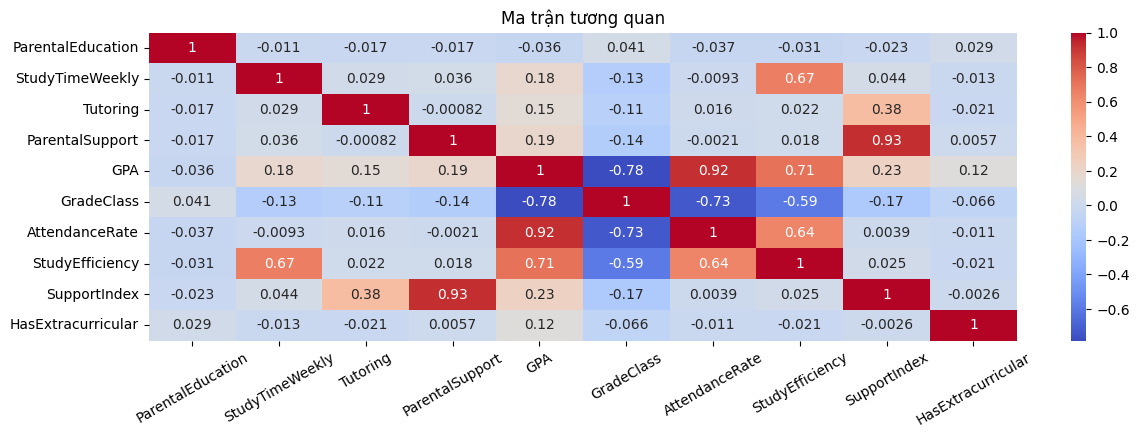

In [24]:
df_no_fe = df
df = add_features(df_no_fe)
plt.figure(figsize=(14,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Ma trận tương quan')
plt.xticks(rotation=30)
plt.show()

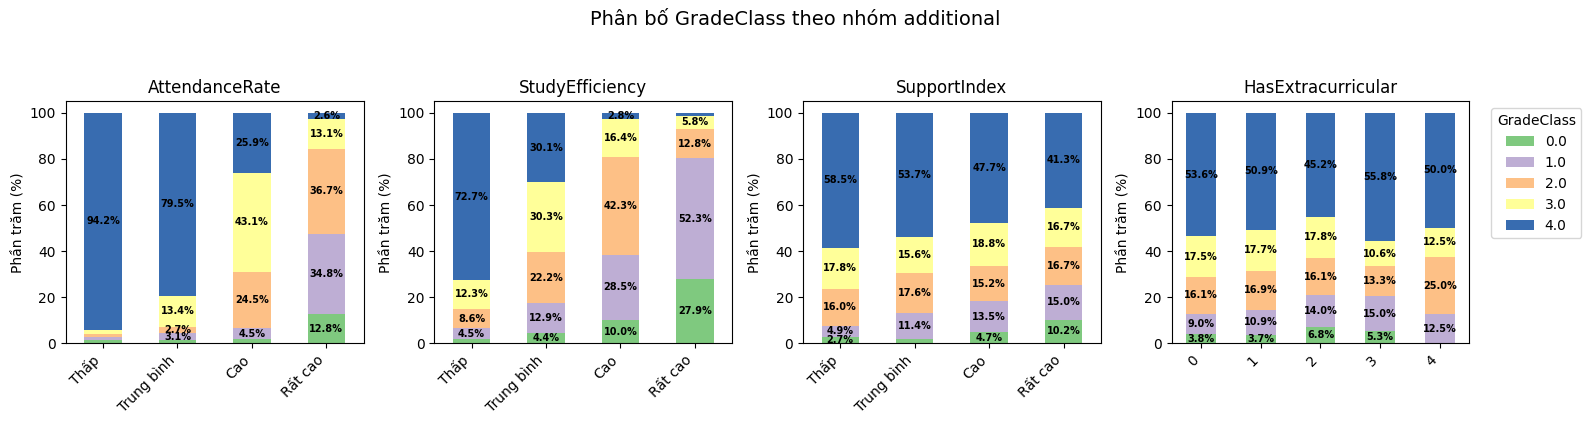

In [25]:
additional_features = ['AttendanceRate', 'StudyEfficiency', 'SupportIndex', 'HasExtracurricular']
numeric_columns.extend(['AttendanceRate', 'StudyEfficiency', 'SupportIndex'])
categoric_columns.extend(['HasExtracurricular'])
fig, axes = plot_percentage_stacked_bars(df=df, features=additional_features, group_name='additional', target_col='GradeClass', figsize=(16, 4))
plt.show()

### Đánh giá hiệu quả của các biến mới được tạo ra

Sau quá trình Feature Engineering, bốn biến mới bao gồm `AttendanceRate`, `StudyEfficiency`, `SupportIndex`, và `HasExtracurricular` đã được xây dựng nhằm cải thiện khả năng phân loại GradeClass.

Quan sát từ biểu đồ phân bố nhóm additional:
- Các biến mới cho thấy sự phân hóa rõ rệt giữa các mức GradeClass, đặc biệt ở các mức giá trị "Cao" và "Rất cao".
- Ví dụ: `AttendanceRate` và `StudyEfficiency` thể hiện xu hướng càng cao thì tỷ lệ thuộc các lớp GradeClass tốt (0, 1) càng lớn.

Quan sát từ ma trận tương quan:
- Các biến mới có tương quan mạnh hơn với GradeClass so với nhiều biến gốc trước đó.
  - `AttendanceRate` có hệ số tương quan -0.73 với GradeClass.
  - `StudyEfficiency` có hệ số tương quan -0.59.
  - `SupportIndex` và `HasExtracurricular` tuy tương quan thấp hơn nhưng đã tốt hơn rất nhiều so với các biến mà nó thay thế.

Nhận xét:
- Các biến mới đã thay thế hiệu quả cho các biến cũ như `Extracurricular`, `Sports`, `Music`, `Volunteering`, `Gender`, `Ethnicity`, vốn không có tương quan rõ rệt với GradeClass và không đóng góp nhiều trong PCA hoặc các phân tích trước đó.
- Việc tạo biến mới giúp mô hình hóa dễ dàng hơn, tăng khả năng phân tách các nhóm chất lượng học tập, đồng thời giảm nhiễu từ những đặc trưng kém liên quan.

## **Phần 3: Model - Đánh giá - Phân tích lỗi**

### **Quy trình phân cụm - đánh giá - phân tích lỗi gồm các bước sau**:
  - **Tiền xử lý & Feature Engineering**: 
      - Đối với biến numerical: Áp dụng chuẩn hóa về phân phối chuẩn tắc bằng StandardScaler.
      - Đối với biến categorical: Thực hiện one-hot encoding toàn bộ các biến phân loại.
      - Lưu lại nhãn `GradeClass`để làm target riêng biệt để phục vụ phân tích/đánh giá về sau.
  - **Các mô hình phân cụm**: Áp dụng K-Means, Phân cấp (Hierarchical) và GMM trên cùng bộ dữ liệu đã tạo đặc trưng.  
  - **Chọn hyperparameter phù hợp**:  
    - K-Means: Phương pháp Elbow với WCSS để xác định số cụm tối ưu.  
    - Hierarchical: Vẽ dendrogram và chọn ngưỡng cắt (mean của các khoảng cách lớn nhất) để xác định số cụm.  
    - GMM: Đánh giá BIC theo số thành phần, chọn giá trị có BIC thấp nhất.  
  - **Trực quan hóa kết quả**:  
    - Biểu đồ scatter trên không gian PCA 2 chiều, đánh dấu tâm cụm để thấy cấu trúc.  
    - Bản đồ màu thể hiện khoảng cách chuẩn hóa đến tâm cụm (phát hiện outlier nếu khoảng cách xa tậm cụm).  
    - Biểu đồ cột chồng phân phối GradeClass trong mỗi cụm để đánh giá mức độ học lực.  
  - **Đánh giá chất lượng**:  
    - **Silhouette Score**: 
         - **Định nghĩa**: Đo lường mức độ tương đồng của một đối tượng với cụm của nó (gắn kết) so với các cụm lân cận (tách biệt).
         - **Thang đo**: Từ -1 đến 1, với giá trị càng cao càng tốt.
         - **Lý do chọn**: Metric này cung cấp cái nhìn trực quan về chất lượng phân cụm ở cả cấp độ điểm dữ liệu và toàn cụm, giúp đánh giá xem mỗi đối tượng được phân vào cụm phù hợp đến mức nào.
    - **Davies–Bouldin Index**:
         - **Định nghĩa**: Tính toán tỷ lệ giữa khoảng cách trung bình trong cụm và khoảng cách giữa các tâm cụm.
         - **Thang đo**: Giá trị không âm, càng thấp càng tốt.
         - **Lý do chọn**: Rất phù hợp để đánh giá cụm có hình dạng hypersphere, tập trung vào tính chặt chẽ trong cụm và tính tách biệt giữa các cụm, không phụ thuộc vào số lượng cụm hay thuật toán phân cụm.
         - **Giá trị đánh giá**: DB Index nhỏ chỉ ra rằng các cụm được tách biệt tốt và có độ phân tán thấp bên trong mỗi cụm.
    - **Calinski–Harabasz Index**:
         - **Định nghĩa**: Tính toán tỷ lệ giữa phương sai giữa các cụm và phương sai trong cụm, còn gọi là Variance Ratio Criterion.
         - **Thang đo**: Giá trị không âm, càng cao càng tốt.
         - **Lý do chọn**: Đặc biệt hiệu quả khi đánh giá cụm có hình dạng convex, nhạy với sự phân tách giữa các cụm và mức độ tập trung của dữ liệu trong mỗi cụm.
         - **Giá trị đánh giá**: CH Index cao cho thấy các cụm được định nghĩa tốt và tách biệt rõ ràng.
    - **So sánh và kết hợp các metric**:
         - Việc sử dụng cả ba metric giúp bù đắp hạn chế của từng phương pháp: Silhouette Score nhạy với cụm hình dạng bất kỳ, Davies-Bouldin tốt với cụm hình cầu, và Calinski-Harabasz hiệu quả với cụm lồi.
         - Kết hợp các chỉ số này giúp đánh giá toàn diện về chất lượng phân cụm từ nhiều góc độ: độ chặt chẽ nội cụm, khoảng cách giữa các cụm, và tỷ lệ phương sai.
         - Trường hợp lý tưởng là mô hình có Silhouette Score cao, Davies-Bouldin thấp và Calinski-Harabasz cao sẽ được coi là mô hình phân cụm tối ưu.
  - **Phân tích phụ**:  
    - Chạy lại quy trình trên dữ liệu gốc (chưa feature engineering) để so sánh sự khác biệt về metric và cấu trúc cụm.  
  - **Đối chiếu với GradeClass**:  
    - Sử dụng GradeClass làm ground truth (số cluster bằng số lớp điểm) để đánh giá hiệu quả phân cụm so với nhãn thực.  

In [26]:
def find_optimal_clusters_kmeans(data, max_clusters=10, df_compare=True):
    """Tính WCSS cho các số cụm khác nhau, vẽ Elbow plot và trả về số cụm tối ưu cho K-Means."""
    wcss = []
    for n_clusters in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    if not df_compare:
        plt.figure(figsize=(13, 4))
        plt.subplot(1, 3, 1)
        plt.plot(range(1, max_clusters + 1), wcss, 'bo-')
        plt.xlabel('Số lượng cụm')
        plt.ylabel('WCSS')
        plt.title('Phương pháp Elbow cho K-Means')
        plt.grid(True)
        kl = KneeLocator(range(1, max_clusters + 1), wcss, curve='convex', direction='decreasing')
        optimal_clusters = kl.elbow if kl.elbow else 2
        plt.axvline(x=optimal_clusters, color='r', linestyle='--', label=f'Số cụm tối ưu: {optimal_clusters}')
        plt.legend()
    else:
        kl = KneeLocator(range(1, max_clusters + 1), wcss, curve='convex', direction='decreasing')
        optimal_clusters = kl.elbow if kl.elbow else 2
    return optimal_clusters

In [ ]:
def plot_dendrogram(data, max_samples=100, df_compare=True):
    """Lấy mẫu dữ liệu, tạo dendrogram phân cấp với phương pháp Ward và đề xuất ngưỡng cắt để chọn số cụm."""
    if data.shape[0] > max_samples:
        indices = np.random.choice(data.shape[0], max_samples, replace=False)
        sampled_data = data[indices]
    else:
        sampled_data = data
    linked = linkage(sampled_data, method='ward')
    if not df_compare:
        plt.subplot(1, 3, 2)
        dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
        plt.title('Dendrogram phân cụm phân cấp')
        plt.xlabel('Chỉ mục mẫu')
        plt.ylabel('Khoảng cách')
        plt.axhline(y=linked[-5:, 2].mean(), color='r', linestyle='--', label='Ngưỡng cắt đề xuất')
        plt.legend()
    heights = linked[:, 2]
    diffs = np.diff(heights)
    largest_diff_idx = np.argmax(diffs[-15:]) - 15 if len(diffs) > 15 else np.argmax(diffs)
    optimal_clusters = len(heights) - largest_diff_idx
    if optimal_clusters > 10: optimal_clusters = 5
    elif optimal_clusters < 2: optimal_clusters = 2
    return optimal_clusters

In [ ]:
def find_optimal_components_gmm(data, max_components=7, df_compare=True):
    """Tính BIC/AIC cho GMM với các số thành phần khác nhau, vẽ đồ thị BIC và trả về số thành phần tối ưu."""
    n_components_range = range(1, max_components + 1)
    bic_scores, aic_scores = [], []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(data)
        bic_scores.append(gmm.bic(data))
        aic_scores.append(gmm.aic(data))
    if not df_compare:
        plt.subplot(1, 3, 3)
        plt.plot(n_components_range, bic_scores, 'bo-')
        plt.xlabel('Số lượng thành phần')
        plt.ylabel('BIC score')
        plt.title('BIC Score cho GMM\n(Thấp hơn là tốt hơn)')
        plt.grid(True)
        optimal_components_bic = n_components_range[np.argmin(bic_scores)]
        plt.axvline(x=optimal_components_bic, color='r', linestyle='--', label=f'Số thành phần tối ưu: {optimal_components_bic}')
        plt.legend()
    else:
        optimal_components_bic = n_components_range[np.argmin(bic_scores)]
    return optimal_components_bic

In [ ]:
def apply_clustering(data, algorithm, **params):
    """Khởi tạo và chạy mô hình phân cụm (KMeans, AgglomerativeClustering hoặc GMM), trả về nhãn, mô hình và tâm cụm (nếu có)."""
    model = algorithm(**params)
    if isinstance(model, GaussianMixture):
        model.fit(data)
        labels = model.predict(data)
        centers = model.means_
    else:
        labels = model.fit_predict(data)
        centers = model.cluster_centers_ if isinstance(model, KMeans) else None
    return labels, model, centers

In [ ]:
def evaluate_clustering(X, labels, method_name):
    """Tính toán các chỉ số đánh giá (Silhouette, Davies–Bouldin, Calinski–Harabasz) và phân tích lỗi (cluster trống, quá nhỏ/lớn, imbalance)."""
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    if n_clusters <= 1:
        return {'silhouette': float('nan'), 'davies_bouldin': float('nan'), 'calinski_harabasz': float('nan'), 'noise_percentage': 0.0, 
                'error_analysis': {'empty_clusters': 0, 'small_clusters': 0, 'large_clusters': 0, 'imbalance_ratio': float('nan')}}
    try: silhouette = silhouette_score(X, labels)
    except: silhouette = float('nan')
    try: davies_bouldin = davies_bouldin_score(X, labels)
    except: davies_bouldin = float('nan')
    try: calinski_harabasz = calinski_harabasz_score(X, labels)
    except: calinski_harabasz = float('nan')
    cluster_sizes = np.array([np.sum(labels == i) for i in unique_labels])
    total_samples = len(labels)
    empty_clusters = np.sum(cluster_sizes == 0)
    small_clusters = np.sum((cluster_sizes > 0) & (cluster_sizes < total_samples * 0.05))
    large_clusters = np.sum(cluster_sizes > total_samples * 0.5)
    non_empty_sizes = cluster_sizes[cluster_sizes > 0]
    imbalance_ratio = np.max(non_empty_sizes) / np.min(non_empty_sizes) if len(non_empty_sizes) > 1 else float('nan')
    error_analysis = {'empty_clusters': empty_clusters, 'small_clusters': small_clusters, 'large_clusters': large_clusters, 
                      'imbalance_ratio': imbalance_ratio, 'cluster_sizes': cluster_sizes.tolist()}
    return {'silhouette': silhouette, 'davies_bouldin': davies_bouldin, 'calinski_harabasz': calinski_harabasz, 
            'noise_percentage': 0.0, 'error_analysis': error_analysis}

In [ ]:
def visualize_clusters_enhanced(X, labels, method_name, target_data=None):
    """Dựng không gian 2D bằng PCA, hiển thị scatter plot với tâm cụm, bản đồ outlier và phân phối GradeClass theo cụm."""
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    unique_labels = np.unique(labels)
    centroids = np.array([np.mean(X_pca[labels == i], axis=0) for i in unique_labels if np.sum(labels == i) > 0])
    distances = np.zeros(len(X_pca))
    for i, label in enumerate(unique_labels):
        mask = (labels == label)
        if np.sum(mask) > 0:
            centroid = centroids[i]
            distances[mask] = np.sqrt(np.sum((X_pca[mask] - centroid)**2, axis=1))
    max_dist = np.max(distances) if len(distances) > 0 else 1
    normalized_distances = distances / max_dist if max_dist > 0 else distances
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    scatter = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
    axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=100)
    axes[0].set_title(f'PCA - {method_name}')
    plt.colorbar(scatter, ax=axes[0], label='Cụm')
    scatter = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=normalized_distances, cmap='YlOrRd', alpha=0.6)
    plt.colorbar(scatter, ax=axes[1], label='Khoảng cách chuẩn hóa')
    axes[1].set_title(f'Mức độ outlier tiềm năng')
    if target_data is not None and 'GradeClass' in target_data.columns:
        df_analysis = pd.DataFrame({'cluster': ['Cụm ' + str(l) for l in labels]})
        for col in target_data.columns: df_analysis[col] = target_data[col].values
        cross_tab = pd.crosstab(df_analysis['cluster'], df_analysis['GradeClass'])
        cross_tab.plot(kind='bar', stacked=True, ax=axes[2])
        axes[2].set_title('Phân phối GradeClass theo cụm')
        axes[2].set_ylabel('Số lượng')
        axes[2].tick_params(axis='x', rotation=45)
        axes[2].grid(True, alpha=0.3)
        axes[2].legend(title='GradeClass')
    plt.tight_layout()
    plt.show()
    return distances

In [ ]:
def create_comparison_table(results):
    """Tổng hợp kết quả phân cụm của các mô hình vào DataFrame, vẽ biểu đồ so sánh các metric và trả về bảng kết quả."""
    comparison_data = []
    for method, data in results.items():
        method_name = {'kmeans': 'K-Means', 'hierarchical': 'Hierarchical', 'gmm': 'GMM'}.get(method, method)
        n_clusters = len(np.unique(data['labels']))
        labels = data['labels']
        avg_cluster_size = np.mean([np.sum(labels == i) for i in np.unique(labels)])
        error_analysis = data['scores']['error_analysis']
        comparison_data.append({'Method': method_name, 'Number of Clusters': n_clusters, 'Average Cluster Size': avg_cluster_size, 
            'Silhouette Score': data['scores']['silhouette'], 'Davies-Bouldin Index': data['scores']['davies_bouldin'], 
            'Calinski-Harabasz Index': data['scores']['calinski_harabasz'], 'Empty Clusters': error_analysis['empty_clusters'], 
            'Small Clusters': error_analysis['small_clusters'], 'Large Clusters': error_analysis['large_clusters'], 
            'Imbalance Ratio': error_analysis['imbalance_ratio']})
    comparison_df = pd.DataFrame(comparison_data)
    pd.set_option('display.float_format', '{:.4f}'.format)
    comparison_df['Average Cluster Size'] = comparison_df['Average Cluster Size'].map('{:.1f}'.format)
    plt.figure(figsize=(12, 3))
    metrics = [
        ('Silhouette Score', 'Cao hơn tốt hơn', (-0.1, 1.0)),
        ('Davies-Bouldin Index', 'Thấp hơn tốt hơn', None),
        ('Calinski-Harabasz Index', 'Cao hơn tốt hơn', None),
        ('Imbalance Ratio', 'Thấp hơn tốt hơn', None)
    ]
    for i, (metric, note, ylimit) in enumerate(metrics):
        plt.subplot(1, 4, i+1)
        sns.barplot(x='Method', y=metric, data=comparison_df)
        plt.title(f"{metric}\n({note})", fontsize=8)
        plt.xticks(fontsize=7, rotation=15)
        plt.yticks(fontsize=7)
        if ylimit: plt.ylim(*ylimit)
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return comparison_df

In [ ]:
def prepare_data(df):
    """Chuẩn hóa các biến số, one-hot encode biến categorical, tách nhãn GradeClass (nếu có) và trả về X đã xử lý cùng target."""
    df = df.copy()
    if 'StudentID' in df.columns:
        df = df.drop(['StudentID'], axis=1)
    target = df[['GradeClass']] if 'GradeClass' in df.columns else None
    if target is not None:
        df = df.drop(['GradeClass'], axis=1)
    numeric_features = [col for col in numeric_columns if col in df.columns]
    if numeric_features:
        scaler = StandardScaler()
        df[numeric_features] = scaler.fit_transform(df[numeric_features])
    categorical_features = [col for col in categoric_columns if col in df.columns]
    if categorical_features:
        df = pd.get_dummies(df, columns=categorical_features, drop_first=False)
    return df, target

In [ ]:
def summarize_clusters(df_original, best_labels):
    """In ra đặc điểm trung bình của từng cụm."""
    unique_clusters = np.unique(best_labels)
    numeric_features = [col for col in df_original.columns if col in numeric_columns and col != 'StudentID' and col != 'GradeClass']
    df_with_clusters = df_original.copy()
    df_with_clusters['cluster'] = best_labels
    summary_data = []
    for cluster in unique_clusters:
        cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster]
        cluster_size = len(cluster_data)
        cluster_info = {"Cụm": f"Cụm {cluster}", "Số lượng": cluster_size, "Tỷ lệ": f"{cluster_size / len(df_original) * 100:.1f}%"}
        for feature in numeric_features:
            if feature in cluster_data.columns:
                cluster_info[feature] = f"{cluster_data[feature].mean():.2f}"
        for feature in categoric_columns:
            if feature in cluster_data.columns and feature != 'StudentID' and feature != 'GradeClass':
                value_counts = cluster_data[feature].value_counts(normalize=True)
                if not value_counts.empty:
                    top_value = value_counts.index[0]
                    top_freq = value_counts.iloc[0] * 100
                    cluster_info[feature] = f"{top_value} ({top_freq:.1f}%)"
        summary_data.append(cluster_info)
    summary_df = pd.DataFrame(summary_data)
    return summary_df

def add_cluster_summary_to_analysis():
    """Thêm bảng tóm tắt các đặc điểm của từng cụm vào phân tích."""
    best_method_name = max(results.items(), key=lambda x: x[1]['scores']['silhouette'])[0]
    best_labels = results[best_method_name]['labels']
    print(f"\nĐẶC ĐIỂM TRUNG BÌNH CỦA CÁC CỤM (PHƯƠNG PHÁP {best_method_name.upper()}):")
    summary = summarize_clusters(df, best_labels)
    display_table(summary)

In [ ]:
def run_clustering_analysis(data, target=None, df_compare=False):
    """Điều phối toàn bộ quy trình phân cụm chính và phụ, từ chọn hyperparameter, chạy mô hình, đánh giá, trực quan hóa đến so sánh kết quả."""
    results = {}
    plt.figure(figsize=(15, 4))
    optimal_k = find_optimal_clusters_kmeans(data, max_clusters=10, df_compare=df_compare)
    kmeans_labels, kmeans_model, kmeans_centers = apply_clustering(data, KMeans, n_clusters=optimal_k, n_init=10, random_state=42)
    kmeans_scores = evaluate_clustering(data, kmeans_labels, "KMeans")
    optimal_h_clusters = plot_dendrogram(data, max_samples=min(100, data.shape[0]), df_compare=df_compare)
    hc_labels, hc_model, _ = apply_clustering(data, AgglomerativeClustering, n_clusters=optimal_h_clusters, linkage='ward')
    hc_scores = evaluate_clustering(data, hc_labels, "Phân cụm phân cấp")
    optimal_components = find_optimal_components_gmm(data, max_components=10, df_compare=df_compare)
    gmm_labels, gmm_model, gmm_centers = apply_clustering(data, GaussianMixture, n_components=optimal_components, random_state=42)
    gmm_scores = evaluate_clustering(data, gmm_labels, "GMM")
    plt.tight_layout()
    plt.show()
    results['kmeans'] = {'labels': kmeans_labels, 'scores': kmeans_scores, 'optimal_k': optimal_k}
    results['hierarchical'] = {'labels': hc_labels, 'scores': hc_scores, 'optimal_clusters': optimal_h_clusters}
    results['gmm'] = {'labels': gmm_labels, 'scores': gmm_scores, 'optimal_components': optimal_components}
    if not df_compare:
        visualize_clusters_enhanced(data, kmeans_labels, "K-Means", target_data=target)
        visualize_clusters_enhanced(data, hc_labels, "Hierarchical", target_data=target)
        visualize_clusters_enhanced(data, gmm_labels, "GMM", target_data=target)
    comparison_df = create_comparison_table(results)
    if not df_compare:
        best_methods = {
            'Silhouette Score': comparison_df.loc[comparison_df['Silhouette Score'].idxmax()]['Method'],
            'Davies-Bouldin Index': comparison_df.loc[comparison_df['Davies-Bouldin Index'].idxmin()]['Method'],
            'Calinski-Harabasz Index': comparison_df.loc[comparison_df['Calinski-Harabasz Index'].idxmax()]['Method'],
            'Imbalance Ratio': comparison_df.loc[comparison_df['Imbalance Ratio'].idxmin()]['Method']
        }
        print("\nPHƯƠNG PHÁP TỐT NHẤT THEO MỖI CHỈ SỐ:")
        for metric, method in best_methods.items():
            print(f"{metric}: {method}")
    return results, comparison_df

In [ ]:
def evaluate_gradeclass_clustering(df):
    """Xem GradeClass như nhãn clustering thực, tính các metric đánh giá và trả về DataFrame so sánh với ground truth."""
    if 'GradeClass' not in df: return None
    X = prepare_data(df)[0].values
    labels = df['GradeClass'].astype('category').cat.codes
    scores = evaluate_clustering(X, labels, "")
    n = len(np.unique(labels))
    avg_size = np.mean([np.sum(labels == i) for i in np.unique(labels)])
    e = scores['error_analysis']
    df_out = pd.DataFrame([{
        'Method': 'GradeClass', 'Number of Clusters': n, 'Average Cluster Size': f'{avg_size:.1f}',
        'Silhouette Score': scores['silhouette'], 'Davies-Bouldin Index': scores['davies_bouldin'],
        'Calinski-Harabasz Index': scores['calinski_harabasz'], 'Empty Clusters': e['empty_clusters'],
        'Small Clusters': e['small_clusters'], 'Large Clusters': e['large_clusters'], 'Imbalance Ratio': e['imbalance_ratio']
    }])
    return df_out

In [ ]:
# 1. Phân tích chính
data, target = prepare_data(df)
print("PHÂN TÍCH PHÂN CỤM DỮ LIỆU SAU KHI FEATURE ENGINEERING")
results, comparison = run_clustering_analysis(data.values, target)
add_cluster_summary_to_analysis()
print("\n" + "="*40)

# 2. Phân tích khi không có FE
data_auxiliary, target_auxiliary = prepare_data(df_no_fe) 
print("\nPHÂN TÍCH PHỤ")
print("\nSO SÁNH DỮ LIỆU TRƯỚC KHI FEATURE ENGINEERING:")
results_aux, comparison_aux = run_clustering_analysis(data_auxiliary.values, target_auxiliary, df_compare=True)
display_table(comparison_aux)
print("\n" + "="*40)

# 3. So sánh với GradeClass
grade_comparison = evaluate_gradeclass_clustering(df_no_fe)
if grade_comparison is not None:
    print("\nSO SÁNH VỚI GRADECLASS CHÍNH LÀ SỐ CỤM:")
    display_table(grade_comparison)
print("\n" + "="*40)

# 4. Gộp tất cả kết quả để so sánh
comparisons_to_concat = [comparison, comparison_aux]
if grade_comparison is not None:
    comparisons_to_concat.append(grade_comparison)
all_comparison = pd.concat(comparisons_to_concat, ignore_index=True)
all_comparison["feature engineering"] = ["có"] * 3 + ["không"] * (len(all_comparison) - 3)
print("\nBẢNG TỔNG HỢP SO SÁNH TẤT CẢ:")
display_table(all_comparison)

**Nhận xét về kết quả phân cụm**:
  - **K-Means (sau feature engineering(FE))**:  
    - Silhouette tăng từ 0.0862 → 0.1567 (tăng 82%), Davies–Bouldin giảm từ 2.7799 → 1.8736 (giảm 33%), Calinski–Harabasz tăng từ 284.9107 → 524.7991 (tăng 84%).
    - Chọn 4 cụm ổn định, Imbalance Ratio duy trì ở mức thấp từ 1.1223 → 1.1279, cho thấy các cụm phân phối gần như cân bằng hoàn hảo.
    - Không có cụm rỗng hay cụm quá nhỏ, phản ánh sự phân phối dữ liệu hiệu quả vào các nhóm có ý nghĩa.
    - Kết quả tốt nhất trong tất cả các phương pháp, chứng tỏ K-Means phù hợp với cấu trúc dữ liệu sau khi đã tối ưu đặc trưng.
  
  - **Hierarchical (sau FE)**:  
    - Silhouette tăng đáng kể (0.0387 → 0.0962, tăng 149%), DB giảm mạnh (3.3531 → 2.1760, giảm 35%), CH tăng mạnh (171.4150 → 354.6610, tăng 107%).
    - Duy trì 5 cụm, cho phép phân tích chi tiết hơn và cải thiện tỉ lệ cân bằng (Imbalance Ratio giảm từ 1.5491 → 2.0090).
    - Mặc dù có nhiều cụm hơn K-Means nhưng vẫn duy trì được chất lượng phân cụm tốt, không có cụm rỗng hoặc quá nhỏ.
    - Chỉ số Silhouette thấp hơn K-Means có thể do việc nhiều cụm hơn làm cho một số cụm gần nhau hơn trong không gian đặc trưng.
  
  - **GMM (sau FE)**:  
    - Silhouette giảm từ 0.0156 → -0.0239 (chuyển sang giá trị âm), DB giảm nhưng vẫn cao (6.0869 → 3.8001, giảm 38%), CH tăng đáng kể (25.3978 → 57.8488, tăng 128%).
    - Số cụm tăng đáng kể từ 5 lên 10, có tới 5 cụm rất nhỏ và Imbalance Ratio cực lớn (92.7143), cho thấy phân mảnh quá mức.
    - Mô hình đã phát hiện các cụm phức tạp hơn nhưng có thể đã tạo ra các phân nhóm quá chi tiết không có ý nghĩa thực tế.
    - Silhouette âm cho thấy GMM tạo ra các cụm không phù hợp với cấu trúc tự nhiên của dữ liệu, đang phát hiện nhiễu thay vì mẫu có ý nghĩa.
  
  - **So sánh trước và sau feature engineering**:  
    - Tất cả phương pháp đều cải thiện DB và CH sau khi áp dụng feature engineering, chứng tỏ tầm quan trọng của bước tiền xử lý này.
    - K-Means hưởng lợi rõ nhất với mức cải thiện lớn nhất ở cả ba chỉ số và duy trì sự cân bằng gần như hoàn hảo giữa các cụm.
    - Hierarchical cải thiện đáng kể về cả chỉ số và khả năng phân nhóm, đạt được sự cân bằng tốt hơn giữa các cụm.
    - GMM cải thiện một số chỉ số nhưng kém ổn định nhất, tăng quá nhiều số lượng cụm và tạo ra sự mất cân bằng nghiêm trọng, thậm chí làm cho Silhouette score chuyển sang giá trị âm.
    - Feature engineering đã giúp các thuật toán phát hiện cấu trúc cụm rõ ràng hơn, đặc biệt là đối với K-Means và Hierarchical.
  
  - **Đối chiếu với GradeClass làm nhãn**:  
    - GradeClass (5 cluster) có chỉ số Silhouette thấp (0.0300) và DB cực cao (9.6032), CH thấp (111.5620), chứng tỏ cách phân loại này không phản ánh cấu trúc tự nhiên trong dữ liệu.
    - Imbalance Ratio cao (11.3178) với 1 cụm nhỏ, 1 cụm lớn, cho thấy sự mất cân bằng trong cách phân loại ban đầu.
    - Tất cả phương pháp phân cụm tự động sau FE đều vượt trội hơn hẳn GradeClass về mọi chỉ số đánh giá chất lượng cụm.
    - Kết quả này chứng minh phân cụm dựa trên dữ liệu sau khi được xử lý đặc trưng phát hiện ra các nhóm học sinh có đặc điểm tương đồng hiệu quả hơn nhiều so với cách phân loại thủ công theo điểm số.

**Nhận xét chi tiết về các cụm từ K-means**:
- **Cụm 0 - "Học sinh trung bình có nền tảng ổn định" (23.2%)**:
    - GPA trung bình (2.50), thời gian học vừa phải (4.86 giờ/tuần), tỷ lệ đi học cao (76%).
    - Hiệu quả học tập khá (3.68), chỉ số hỗ trợ trung bình (2.31).
    - Phân phối GradeClass tập trung ở mức trung bình-khá (30.1% GradeClass 2, 34.8% GradeClass 3).
    - Đặc trưng: Học sinh đi học đều đặn, kết quả ổn định nhưng chưa xuất sắc, thời gian đầu tư cho học tập không nhiều.
- **Cụm 1 - "Học sinh yếu nhưng được hỗ trợ tốt" (24.5%)**:
    - GPA thấp (1.38), tỷ lệ đi học thấp (28%), thời gian học trung bình (9.50 giờ/tuần).
    - Hiệu quả học tập thấp (2.54) nhưng có chỉ số hỗ trợ cao nhất (3.50), 60.7% có sự hỗ trợ từ phụ huynh ở mức cao.
    - Phân phối GradeClass chủ yếu ở mức thấp nhất (83.1% GradeClass 4).
    - Đặc trưng: Học sinh gặp khó khăn trong học tập dù được hỗ trợ nhiều, cho thấy có thể có các rào cản khác ảnh hưởng đến việc học.
- **Cụm 2 - "Học sinh xuất sắc chủ động" (26.2%)**:
    - GPA cao nhất (2.79), thời gian học nhiều nhất (14.94 giờ/tuần), tỷ lệ đi học cao (75%).
    - Hiệu quả học tập vượt trội (11.04), gấp 3-4 lần các cụm khác, chỉ số hỗ trợ khá (2.59).
    - Phân phối GradeClass đa dạng với tỷ lệ cao ở các mức tốt (10.7% GradeClass 0, 26.2% GradeClass 1, 31.6% GradeClass 2).
    - Đặc trưng: Học sinh chăm chỉ, có kỷ luật tự giác, học hiệu quả cao và đạt kết quả tốt.
- **Cụm 3 - "Học sinh yếu thiếu hỗ trợ" (26.2%)**:
    - GPA thấp nhất (0.99), tỷ lệ đi học thấp (28%), thời gian học trung bình (9.21 giờ/tuần).
    - Hiệu quả học tập thấp (2.50) và chỉ số hỗ trợ thấp nhất (1.35), với chỉ 40.3% có sự hỗ trợ từ phụ huynh ở mức trung bình.
    - Phân phối GradeClass dồn vào mức thấp nhất (92.5% GradeClass 4).
    - Đặc trưng: Học sinh gặp khó khăn nghiêm trọng trong học tập và thiếu hỗ trợ, đây là nhóm rủi ro cao nhất cần can thiệp.
- **Yếu tố quan trọng phân biệt các cụm**:
    1. **Hiệu quả học tập** - khác biệt lớn nhất giữa Cụm 2 (11.04) và các cụm còn lại (2.50-3.68).
    2. **Chỉ số hỗ trợ** - phân biệt Cụm 1 (3.50) và Cụm 3 (1.35), mặc dù cả hai đều có GPA thấp.
    3. **Thời gian học** - Cụm 2 dành nhiều thời gian nhất (14.94), trong khi Cụm 0 ít nhất (4.86).
    4. **Tỷ lệ đi học** - tạo ra hai nhóm rõ rệt: cao (Cụm 0, 2) và thấp (Cụm 1, 3).
- **Ý nghĩa thực tiễn**:
    - **Cụm 0**: Cần động viên tăng thời gian học và hiệu quả học tập để cải thiện kết quả.
    - **Cụm 1**: Cần tập trung vào cải thiện phương pháp học tập, kỷ luật đi học dù đã có hỗ trợ tốt.
    - **Cụm 2**: Nhóm học sinh tiềm năng cao, cần duy trì và phát triển kỹ năng hiện có.
    - **Cụm 3**: Cần can thiệp toàn diện từ cả phía nhà trường và gia đình, ưu tiên số một về hỗ trợ.

# **Phần 4: Kết luận**:
- K-Means với 4 cụm sau feature engineering là phương pháp tối ưu nhất cho việc phân loại học sinh trong bộ dữ liệu này.
- Hierarchical với 5 cụm có thể được xem xét khi cần phân tích chi tiết hơn về các nhóm học sinh khác nhau.
- Không nên sử dụng GMM cho dữ liệu này do sự phân mảnh quá mức và mất cân bằng nghiêm trọng.
- Feature engineering đóng vai trò quyết định trong việc cải thiện chất lượng phân cụm và nên được áp dụng trước khi thực hiện các thuật toán phân cụm.
- Nếu dựa vào GradeClass để đánh số cụm thì không phản ánh đúng cấu trúc tự nhiên của dữ liệu.

# Phần 5: Sử dụng PyCaret để tunning và thử nghiệm các mô hình khác

In [ ]:
from pycaret.clustering import *

data_pycaret = prepare_data(df)[0]  
cluster_setup = setup(data=data_pycaret, silent=True, session_id=42)

,Description,Value
0,session_id,42
1,Original Data,"(2392, 22)"
2,Missing Values,False
3,Numeric Features,22
4,Categorical Features,0
5,Ordinal Features,False
6,High Cardinality Features,False
7,High Cardinality Method,None
8,Transformed Data,"(2392, 22)"
9,CPU Jobs,-1


**K-Means: Phân cụm dựa trên khoảng cách Euclidean**

In [ ]:
kmeans = create_model('kmeans')

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1564,524.7640,1.8755,0,0,0


**Tuning tham số**

In [ ]:
kmeans_tuned = create_model('kmeans', n_clusters=4, init='k-means++', max_iter=500, n_init=20, random_state=42)
print(kmeans_tuned)

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.1566,524.7893,1.8748,0,0,0


KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=500,
       n_clusters=4, n_init=20, n_jobs=-1, precompute_distances='deprecated',
       random_state=42, tol=0.0001, verbose=0)


In [ ]:
plot_model(kmeans_tuned, plot = 'cluster')

In [ ]:
plot_model(kmeans_tuned, plot = 'tsne')

In [ ]:
plot_model(kmeans_tuned, plot = 'elbow') # Elbow plot để xác định số cụm tối ưu

In [ ]:
plot_model(kmeans_tuned, plot = 'silhouette')

In [ ]:
plot_model(kmeans_tuned, plot = 'distance')

In [ ]:
plot_model(kmeans_tuned, plot = 'distribution') # Phân phối các cụm

In [ ]:
plot_model(kmeans_tuned, plot = 'distribution', feature = 'GPA')

In [ ]:
plot_model(kmeans_tuned, plot = 'distribution', feature = 'StudyTimeWeekly')

In [ ]:
plot_model(kmeans_tuned, plot = 'distribution', feature = 'AttendanceRate')

In [ ]:
plot_model(kmeans_tuned, plot = 'distribution', feature = 'StudyEfficiency')

In [ ]:
save_model(kmeans_tuned, 'saved_kmeans_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=False, features_todrop=[],
                                       id_columns=[], ml_usecase='regression',
                                       numerical_features=[],
                                       target='UNSUPERVISED_DUMMY_TARGET',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='most frequent',
                                 fill_value_categorical=None,
                                 fill_value_numerical=Non...
                 ('fix_perfect', 'passthrough'),
                 ('clean_names', Clean_Colum_Names()),
                 ('feature_select', 'passthrough'), ('fix_multi', 'passthrough'),
                 ('dfs', 'passthrough'), ('pca', 'passthrough'),
                 ['trained_model',
                  KMe

**DBSCAN: Phân cụm dựa trên mật độ, phát hiện nhiễu.**

In [ ]:
dbscan = create_model('dbscan')
plot_model(dbscan, plot='cluster')

**OPTICS: Tương tự DBSCAN nhưng cải thiện xử lý dữ liệu có mật độ không đồng đều**

In [ ]:
optics = create_model('optics')
plot_model(optics, plot='cluster')

**Birch Clustering**

In [ ]:
birch = create_model('birch')
plot_model(birch, plot='cluster')

**Spectral Clustering: Phân cụm dựa trên lý thuyết đồ thị**

In [ ]:
spectral = create_model('sc')
plot_model(spectral, plot='cluster')

**Affinity Propagation: phân cụm dựa trên thông điệp trao đổi giữa các điểm dữ liệu**

In [ ]:
ap = create_model('ap')
plot_model(ap, plot='cluster')

**Mean Shift Clustering: Phân cụm dựa trên mật độ**

In [ ]:
meanshift = create_model('meanshift')
plot_model(meanshift, plot='cluster')

**Agglomerative Clustering : Phân cụm phân cấp**

In [ ]:
hclust = create_model('hclust')
plot_model(hclust, plot='cluster')

**K-Modes Clustering: Phân cụm cho dữ liệu phân loại**

In [ ]:
kmodes = create_model('kmodes')
plot_model(kmodes, plot='cluster')

**Tham số**

In [ ]:
print(kmeans)
print(ap)
print(meanshift)
print(hclust)
print(spectral)
print(dbscan)
print(optics)
print(birch)
print(birch)


KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=4, n_init=10, n_jobs=-1, precompute_distances='deprecated',
       random_state=42, tol=0.0001, verbose=0)
AffinityPropagation(affinity='euclidean', convergence_iter=15, copy=True,
                    damping=0.5, max_iter=200, preference=None,
                    random_state='warn', verbose=False)
MeanShift(bandwidth=None, bin_seeding=False, cluster_all=True, max_iter=300,
          min_bin_freq=1, n_jobs=-1, seeds=None)
AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
                        connectivity=None, distance_threshold=None,
                        linkage='ward', memory=None, n_clusters=4)
SpectralClustering(affinity='rbf', assign_labels='kmeans', coef0=1, degree=3,
                   eigen_solver=None, eigen_tol=0.0, gamma=1.0,
                   kernel_params=None, n_clusters=4, n_components=None,
                   n_init=10, n_jobs=-1, n_neighbors=10, random_